In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

df = pd.read_csv("online_purchase_predictor_data.csv")

df.replace("NaN", np.nan, inplace=True)

print("Initial Dataset Shape:", df.shape)
df.head()


Initial Dataset Shape: (100000, 16)


,UserID,BrowsingTime(min),Clicks,PagesVisited,AddToCart,Category,WishlistAdd,BounceRate(min),ExitPage,TimePerPage(min),UserType,Location,SearchKeywords,SessionDuration(min),ProductViews,Purchase
0,User043101,55.29,53.0,11.0,10.0,Electronics,Yes,1.38,Home,4.98,Returning,NaN,shoes,51.04,85.0,1.0
1,User037076,45.20,27.0,47.0,2.0,NaN,Yes,3.45,Search,0.35,Returning,Mumbai,shoes,49.65,67.0,0.0
2,User020848,7.42,11.0,32.0,9.0,Sports,No,1.35,NaN,3.27,New,Dehradun,novel,6.12,4.0,NaN
3,User013368,81.60,19.0,35.0,5.0,Clothing,Yes,2.82,Search,0.89,Returning,Bangalore,novel,81.89,81.0,1.0
4,User061998,103.99,84.0,27.0,7.0,Home,No,20.36,Home,4.97,New,Mumbai,phone,99.81,94.0,1.0


In [3]:

print("Before removing duplicates:", df.shape)
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

if "UserID" in df.columns:
    df.drop("UserID", axis=1, inplace=True)

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
if len(cat_cols) > 0:
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Total missing values after cleaning:", df.isnull().sum().sum())


Before removing duplicates: (100000, 16)
After removing duplicates: (90000, 16)
Total missing values after cleaning: 0


In [4]:

numeric_cols_without_target = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != "Purchase"
]

for col in numeric_cols_without_target:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
              np.where(df[col] > upper, upper, df[col]))

print("Outlier handling completed")


Outlier handling completed


In [5]:

X = df.drop("Purchase", axis=1)
y = df["Purchase"].astype(int)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nTarget Distribution:")
print(y.value_counts())


Features Shape: (90000, 14)
Target Shape: (90000,)

Target Distribution:
Purchase
1    73709
0    16291
Name: count, dtype: int64


In [6]:

X = pd.get_dummies(X, drop_first=True)

print("Encoded Feature Shape:", X.shape)
X.head()


Encoded Feature Shape: (90000, 26)


,BrowsingTime(min),Clicks,PagesVisited,AddToCart,BounceRate(min),TimePerPage(min),SessionDuration(min),ProductViews,Category_Clothing,Category_Electronics,...,ExitPage_Search,UserType_Returning,Location_Chennai,Location_Dehradun,Location_Delhi,Location_Mumbai,SearchKeywords_laptop,SearchKeywords_novel,SearchKeywords_phone,SearchKeywords_shoes
0,55.29,53.0,11.0,10.0,1.38,4.98,51.04,85.0,False,True,...,False,True,True,False,False,False,False,False,False,True
1,45.20,27.0,47.0,2.0,3.45,0.35,49.65,67.0,True,False,...,True,True,False,False,False,True,False,False,False,True
2,7.42,11.0,32.0,9.0,1.35,3.27,6.12,4.0,False,False,...,False,False,False,True,False,False,False,True,False,False
3,81.60,19.0,35.0,5.0,2.82,0.89,81.89,81.0,True,False,...,True,True,False,False,False,False,False,True,False,False
4,103.99,84.0,27.0,7.0,20.36,4.97,99.81,94.0,False,False,...,False,False,False,False,False,True,False,False,True,False


In [7]:

target_corr = X.corrwith(y).abs().sort_values(ascending=False)

print("Correlation with Purchase:")
print(target_corr)

threshold = 0.005
selected_features = target_corr[target_corr > threshold].index.tolist()

if len(selected_features) == 0:
    print("No features selected by threshold. Using all features.")
    X_selected = X
else:
    X_selected = X[selected_features]

print("\nSelected Features:")
print(list(X_selected.columns))
print("\nSelected Feature Shape:", X_selected.shape)


Correlation with Purchase:
AddToCart                0.350672
Clicks                   0.126485
BrowsingTime(min)        0.063784
SessionDuration(min)     0.063699
BounceRate(min)          0.005400
SearchKeywords_phone     0.005372
ExitPage_Search          0.004015
Location_Delhi           0.004004
ExitPage_Product         0.003336
Location_Mumbai          0.002968
Location_Dehradun        0.002815
Location_Chennai         0.002746
PagesVisited             0.002379
TimePerPage(min)         0.002246
SearchKeywords_novel     0.002173
ProductViews             0.002101
SearchKeywords_shoes     0.001669
ExitPage_Home            0.001509
Category_Sports          0.001257
ExitPage_Checkout        0.001086
UserType_Returning       0.000853
Category_Clothing        0.000727
SearchKeywords_laptop    0.000203
Category_Home            0.000176
Category_Electronics     0.000135
WishlistAdd_Yes          0.000059
dtype: float64

Selected Features:
['AddToCart', 'Clicks', 'BrowsingTime(min)', 'SessionD

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (72000, 6)
Testing Shape: (18000, 6)


In [9]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")


Feature scaling completed


In [10]:

log_model = LogisticRegression(max_iter=1000, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
dt_model = DecisionTreeClassifier(random_state=42)
svm_model = SVC(kernel="rbf", random_state=42)

log_model.fit(X_train_scaled, y_train)
y_pred_lr = log_model.predict(X_test_scaled)

knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("All models trained successfully")


All models trained successfully


In [11]:

def evaluate_model(model_name, y_test, y_pred):
    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


In [12]:

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("SVM", y_test, y_pred_svm)



Logistic Regression
Accuracy: 0.8143333333333334
Precision: 0.8347820979678139
Recall: 0.9641161307827975
F1 Score: 0.8947997985394107

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.14      0.21      3258
           1       0.83      0.96      0.89     14742

    accuracy                           0.81     18000
   macro avg       0.65      0.55      0.55     18000
weighted avg       0.77      0.81      0.77     18000


Confusion Matrix:
[[  445  2813]
 [  529 14213]]

KNN
Accuracy: 0.8038333333333333
Precision: 0.8663486046663617
Recall: 0.8991995658662325
F1 Score: 0.8824684618713178

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.37      0.41      3258
           1       0.87      0.90      0.88     14742

    accuracy                           0.80     18000
   macro avg       0.66      0.64      0.64     18000
weighted avg       0.79      0.80      0.80    

In [13]:

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_knn, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_svm, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_knn, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_svm, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_knn, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_svm, zero_division=0)
    ]
})

comparison = comparison.sort_values(by="F1 Score", ascending=False)
comparison


,Model,Accuracy,Precision,Recall,F1 Score
3,SVM,0.819000,0.819000,1.000000,0.900495
0,Logistic Regression,0.814333,0.834782,0.964116,0.894800
1,KNN,0.803833,0.866349,0.899200,0.882468
2,Decision Tree,0.800944,0.878656,0.878239,0.878448


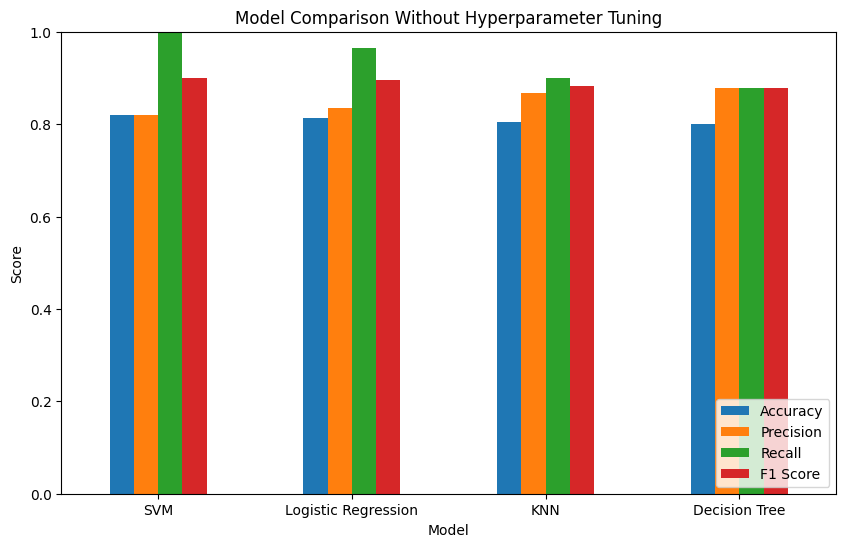

In [14]:

comparison.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison Without Hyperparameter Tuning")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


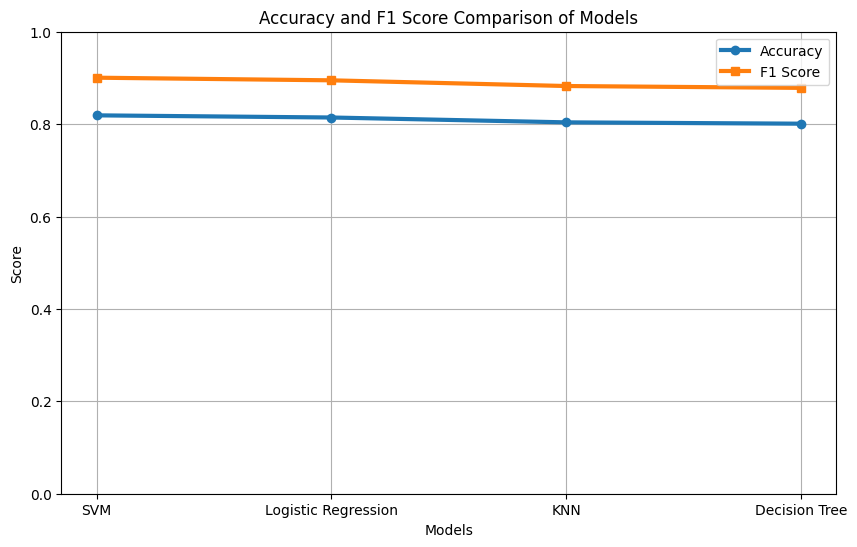

In [15]:

models = comparison["Model"].tolist()
accuracy_scores = comparison["Accuracy"].tolist()
f1_scores = comparison["F1 Score"].tolist()

plt.figure(figsize=(10,6))

plt.plot(models, accuracy_scores, marker="o", linewidth=3, label="Accuracy")
plt.plot(models, f1_scores, marker="s", linewidth=3, label="F1 Score")

plt.title("Accuracy and F1 Score Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()


In [16]:

best_model_name = comparison.iloc[0]["Model"]

print("Best Model Without Hyperparameter Tuning:")
print(best_model_name)


Best Model Without Hyperparameter Tuning:
SVM
